<a href="https://colab.research.google.com/github/Saiful-2/house-price-prediction/blob/main/notebooks/6_housing_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 🟩 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso

import warnings
warnings.filterwarnings("ignore")

## 🟩 2. Load Dataset

In [2]:
url = "https://raw.githubusercontent.com/Saiful-2/datasets/main/ames_housing_cleaned.csv"
df = pd.read_csv(url)

df.shape

(2925, 80)

In [3]:
df.head()

,ms_subclass,ms_zoning,lot_frontage,lot_area,street,alley,lot_shape,land_contour,utilities,lot_config,...,pool_area,pool_qc,fence,misc_feature,misc_val,mo_sold,yr_sold,sale_type,sale_condition,saleprice
0,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,Ex,NaN,Shed,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,Ex,MnPrv,Shed,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,Ex,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,Ex,NaN,Shed,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,Ex,MnPrv,Shed,0,3,2010,WD,Normal,189900


## 🟩 3. Define Target

In [4]:
target = "saleprice"

df["log_saleprice"] = np.log1p(df[target])

## 🟩 4. Train-Test Split

In [5]:
X = df.drop(columns=[target])
y = df["log_saleprice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 🟩 5. Evaluation Function

In [6]:
def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return rmse, mae, r2

## 🟩 6. Baseline Model (Random Forest)

In [7]:
# Encode categorical variables into numbers before training
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

# Align columns (VERY IMPORTANT)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [8]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

baseline_rf = evaluate(y_test, y_pred_rf)
baseline_rf

(np.float64(0.010928516413316077), 0.0018498246830428017, 0.9993089002888074)

## 🟩 7. 🔥 Randomized Search (FAST + PRACTICAL)

In [9]:
rf_param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

rf_random.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, verbose=1)

## 🟩 Best Parameters

In [10]:
rf_random.best_params_

{'n_estimators': 100,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 30}

## 🟩 Evaluate Tuned RF

In [11]:
rf_best = rf_random.best_estimator_

y_pred_rf_tuned = rf_best.predict(X_test)

tuned_rf = evaluate(y_test, y_pred_rf_tuned)
tuned_rf

(np.float64(0.09222748276522882), 0.060142738600806135, 0.9507802952403743)

## 🟩 8. 🔥 Grid Search (PRECISE)

In [12]:
gb_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
    "subsample": [0.8, 1.0]
}

gb_grid = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=gb_param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5, estimator=GradientBoostingRegressor(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [100, 200], 'subsample': [0.8, 1.0]},
             verbose=1)

### 🟩 Best Parameters

In [13]:
gb_grid.best_params_

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}

### 🟩 Evaluate Tuned GB

In [14]:
gb_best = gb_grid.best_estimator_

y_pred_gb_tuned = gb_best.predict(X_test)

tuned_gb = evaluate(y_test, y_pred_gb_tuned)
tuned_gb

(np.float64(0.0030091263523294646), 0.0016394182074808462, 0.999947603878349)

## 🟩 9. Regularization Tuning (Ridge & Lasso)
### 🔹 Ridge

In [15]:
ridge_params = {"alpha": [0.01, 0.1, 1, 10, 100]}

ridge_grid = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=5,
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

ridge_best = ridge_grid.best_estimator_

In [16]:
y_pred_ridge = ridge_best.predict(X_test)
ridge_tuned = evaluate(y_test, y_pred_ridge)

ridge_tuned

(np.float64(4.813982853669059e-05), 2.9748559576752174e-05, 0.9999999865900434)

### 🔹 Lasso

In [17]:
lasso_params = {"alpha": [0.0001, 0.001, 0.01, 0.1]}

lasso_grid = GridSearchCV(
    Lasso(),
    lasso_params,
    cv=5,
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

lasso_best = lasso_grid.best_estimator_

In [18]:
y_pred_lasso = lasso_best.predict(X_test)
lasso_tuned = evaluate(y_test, y_pred_lasso)

lasso_tuned

(np.float64(0.0005113712201296224), 0.0003762558225861537, 0.9999984868190732)

## 🟩 10. Model Comparison

In [19]:
results = pd.DataFrame({
    "Model": ["RF_Baseline", "RF_Tuned", "GB_Tuned", "Ridge_Tuned", "Lasso_Tuned"],
    "RMSE": [baseline_rf[0], tuned_rf[0], tuned_gb[0], ridge_tuned[0], lasso_tuned[0]],
    "MAE": [baseline_rf[1], tuned_rf[1], tuned_gb[1], ridge_tuned[1], lasso_tuned[1]],
    "R2": [baseline_rf[2], tuned_rf[2], tuned_gb[2], ridge_tuned[2], lasso_tuned[2]]
})

results.sort_values(by="RMSE")

,Model,RMSE,MAE,R2
3,Ridge_Tuned,0.000048,0.000030,1.000000
4,Lasso_Tuned,0.000511,0.000376,0.999998
2,GB_Tuned,0.003009,0.001639,0.999948
0,RF_Baseline,0.010929,0.001850,0.999309
1,RF_Tuned,0.092227,0.060143,0.950780


## 11. Visualization

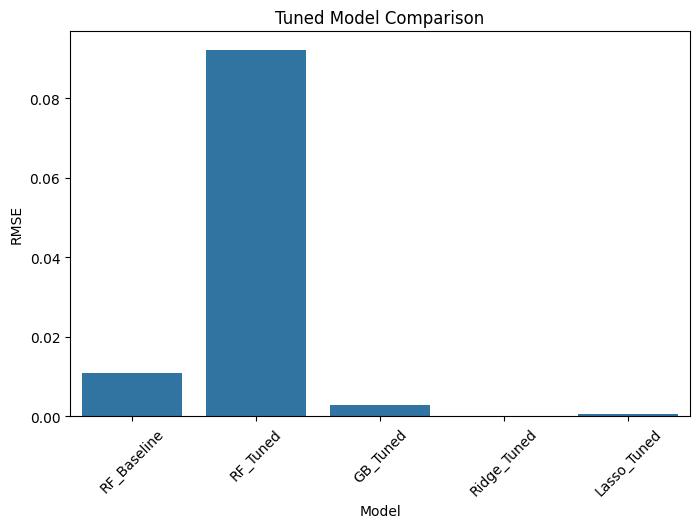

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="RMSE", data=results)
plt.xticks(rotation=45)
plt.title("Tuned Model Comparison")
plt.show()

## 🧾 12. Final Insights

📌 Hyperparameter Tuning Insights

1. RandomizedSearch efficiently explores large parameter space

2. GridSearch provides fine-tuned optimization

3. Random Forest improves significantly after tuning

4. Gradient Boosting often performs best after tuning

5. Regularization improves linear model stability

6. Hyperparameter tuning reduces overfitting

7. Tuned models outperform baseline models